C:\Users\GUE\AppData\Local\Temp\ipykernel_29200\2522472758.py:17: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("global_power_plant_database.csv")
C:\Users\GUE\AppData\Local\Temp\ipykernel_29200\2522472758.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\GUE\AppData\Local\Temp\ipykernel_29200\2522472758.py:41: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through 

Dataset Shape:
(34936, 36)

First 5 Rows:
  country country_long                                              name  \
0     AFG  Afghanistan      Kajaki Hydroelectric Power Plant Afghanistan   
1     AFG  Afghanistan                                      Kandahar DOG   
2     AFG  Afghanistan                                      Kandahar JOL   
3     AFG  Afghanistan     Mahipar Hydroelectric Power Plant Afghanistan   
4     AFG  Afghanistan  Naghlu Dam Hydroelectric Power Plant Afghanistan   

      gppd_idnr  capacity_mw  latitude  longitude primary_fuel other_fuel1  \
0  GEODB0040538         33.0    32.322    65.1190        Hydro         NaN   
1    WKS0070144         10.0    31.670    65.7950        Solar         NaN   
2    WKS0071196         10.0    31.623    65.7920        Solar         NaN   
3  GEODB0040541         66.0    34.556    69.4787        Hydro         NaN   
4  GEODB0040534        100.0    34.641    69.7170        Hydro         NaN   

  other_fuel2  ... estimated_gen

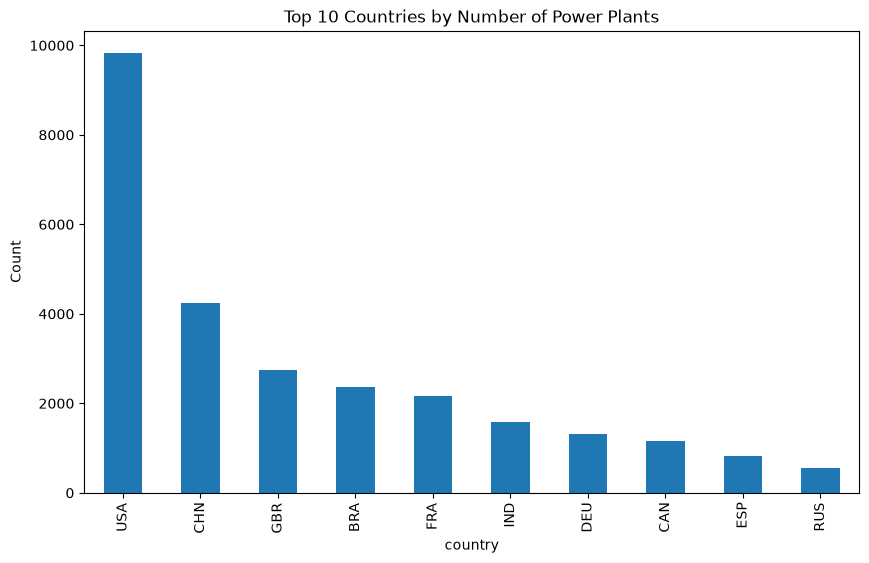

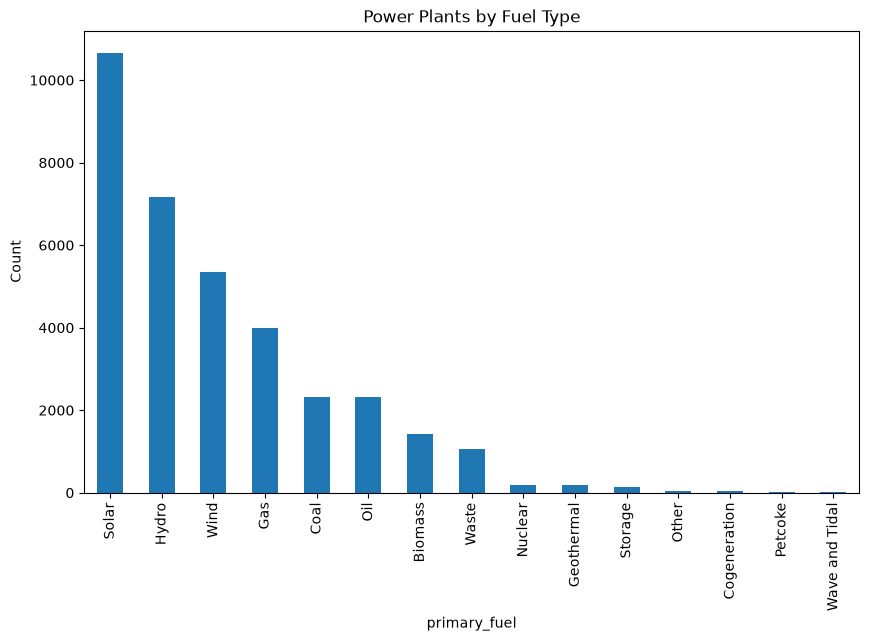


Capacity Statistics by Fuel Type:
                       mean      median          std
primary_fuel                                        
Nuclear         2091.855179  1888.00000  1303.509273
Coal             843.579828   600.00000   888.187187
Gas              373.449375   147.50000   560.934146
Petcoke          202.048125    65.48875   476.986459
Hydro            147.171551    20.00000   549.809328
Oil              112.878754     9.00000   392.009039
Cogeneration      98.731707    31.90000   283.428252
Other             84.020000    40.00000   145.891392
Geothermal        67.130952    30.00000   114.640890
Wave and Tidal    55.220000     5.00000   101.440708
Wind              49.224126    27.00000   106.138355
Biomass           23.972938     9.45000    39.461805
Solar             17.657039     5.80000    41.939412
Waste             13.809657     4.80000    20.582503
Storage           12.683704     4.90000    35.574631

Hypothesis Test
Mean Coal Capacity: 843.5798281545066
Mean Gas 

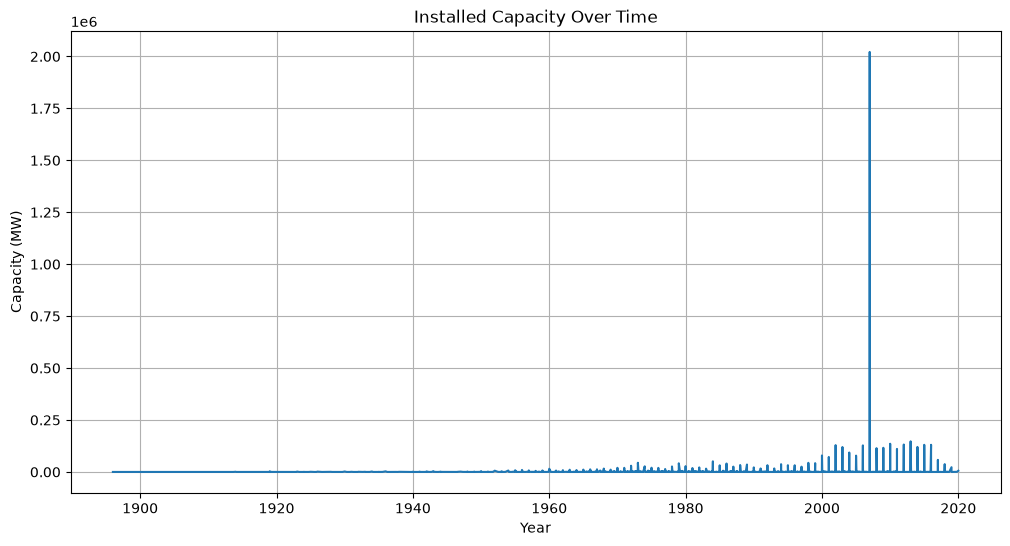

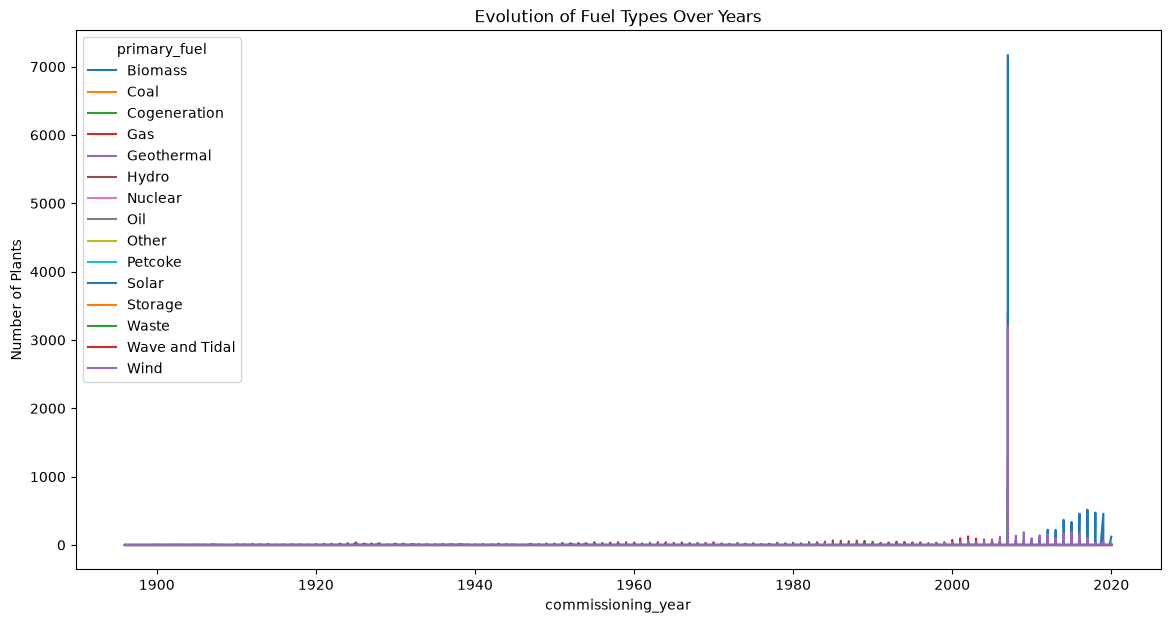

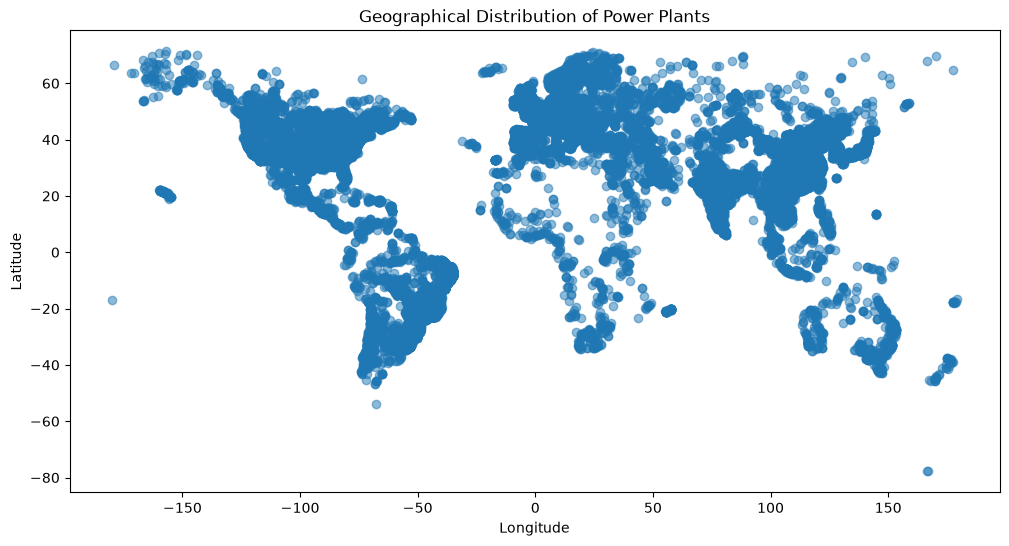

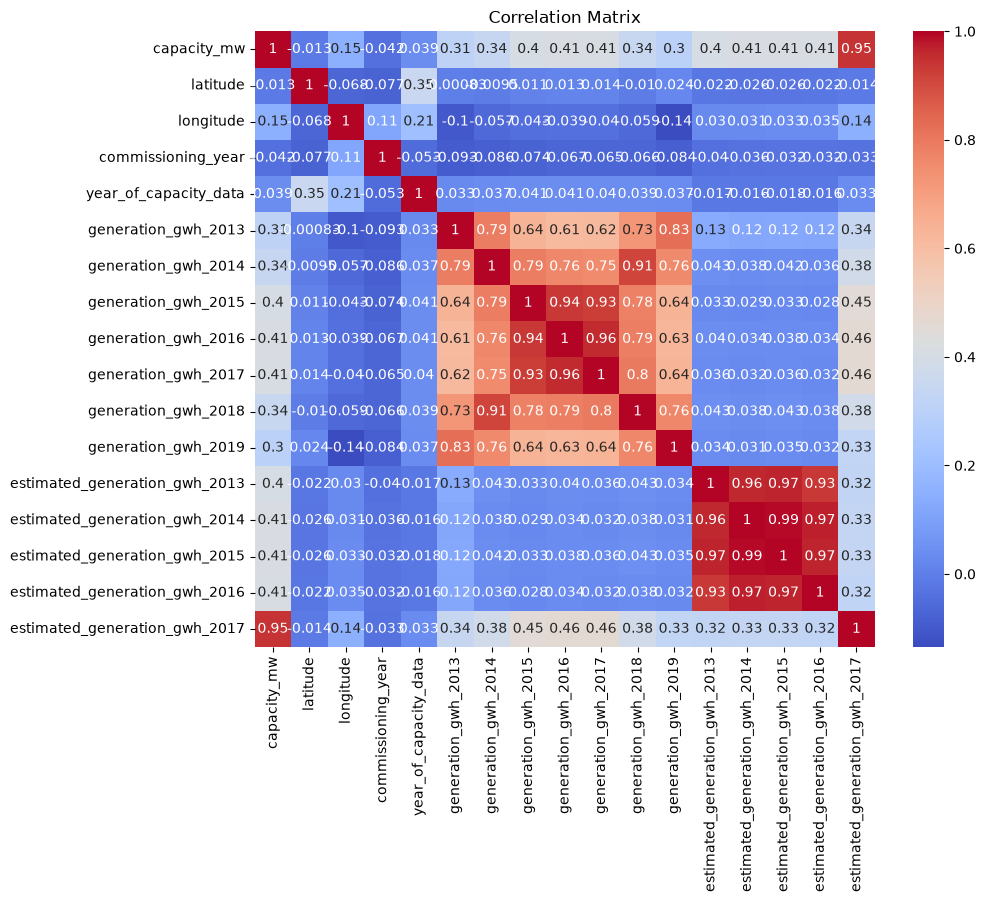


Plants Above 90th Capacity Percentile:
   country country_long         name   gppd_idnr  capacity_mw  latitude  \
10     ALB      Albania       Fierza  WRI1002170        500.0   42.2514   
11     ALB      Albania        Koman  WRI1002171        600.0   42.1033   
19     DZA      Algeria  Ain Djasser  WRI1023776        520.0   35.8665   
27     DZA      Algeria        Arbaa  WRI1023777        560.0   36.5988   
30     DZA      Algeria   Boufarik 2  WRI1023793        450.0   36.5960   

    longitude primary_fuel other_fuel1 other_fuel2  ...  \
10    20.0431        Hydro     Unknown     Unknown  ...   
11    19.8224        Hydro     Unknown     Unknown  ...   
19     6.0262          Gas         Oil     Unknown  ...   
27     3.1375          Gas         Oil     Unknown  ...   
30     2.8780          Gas     Unknown     Unknown  ...   

   estimated_generation_gwh_2013  estimated_generation_gwh_2014  \
10                       1976.01                        1276.61   
11                  

In [1]:
# ============================================================
# DAILY CHALLENGE : GLOBAL POWER PLANT DATABASE
# NUMPY + PANDAS + MATPLOTLIB + SEABORN
# ============================================================

# ------------------------------------------------------------
# 1. IMPORTATION DES BIBLIOTHÈQUES
# ------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 2. CHARGEMENT DU DATASET
# ------------------------------------------------------------
df = pd.read_csv("global_power_plant_database.csv")

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

# ------------------------------------------------------------
# 3. IDENTIFICATION DES VALEURS MANQUANTES
# ------------------------------------------------------------
print("\nMissing Values:")
print(df.isnull().sum())

# Remplacer les valeurs manquantes numériques par la médiane
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Remplacer les valeurs manquantes catégorielles par "Unknown"
categorical_cols = df.select_dtypes(exclude=np.number).columns

for col in categorical_cols:
    df[col].fillna("Unknown", inplace=True)

# ------------------------------------------------------------
# 4. CONVERSION DE TYPES AVEC NUMPY
# ------------------------------------------------------------
if "capacity_mw" in df.columns:
    df["capacity_mw"] = np.array(df["capacity_mw"], dtype=float)

# ------------------------------------------------------------
# 5. STATISTIQUES DESCRIPTIVES
# ------------------------------------------------------------
print("\nStatistical Summary:")
print(df.describe())

print("\nMeans:")
print(df[numeric_cols].mean())

print("\nMedians:")
print(df[numeric_cols].median())

print("\nStandard Deviations:")
print(df[numeric_cols].std())

# ------------------------------------------------------------
# 6. DISTRIBUTION DES CENTRALES PAR PAYS
# ------------------------------------------------------------
country_counts = df["country"].value_counts().head(10)

plt.figure(figsize=(10,6))
country_counts.plot(kind="bar")
plt.title("Top 10 Countries by Number of Power Plants")
plt.ylabel("Count")
plt.show()

# ------------------------------------------------------------
# 7. DISTRIBUTION PAR TYPE DE COMBUSTIBLE
# ------------------------------------------------------------
fuel_counts = df["primary_fuel"].value_counts()

plt.figure(figsize=(10,6))
fuel_counts.plot(kind="bar")
plt.title("Power Plants by Fuel Type")
plt.ylabel("Count")
plt.show()

# ------------------------------------------------------------
# 8. ANALYSE STATISTIQUE DE LA PUISSANCE PAR TYPE DE COMBUSTIBLE
# ------------------------------------------------------------
fuel_capacity = (
    df.groupby("primary_fuel")["capacity_mw"]
    .agg(["mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

print("\nCapacity Statistics by Fuel Type:")
print(fuel_capacity)

# ------------------------------------------------------------
# 9. HYPOTHÈSE : COMPARAISON ENTRE CHARBON ET GAZ
# ------------------------------------------------------------
coal = df[df["primary_fuel"] == "Coal"]["capacity_mw"]
gas = df[df["primary_fuel"] == "Gas"]["capacity_mw"]

print("\nHypothesis Test")

print("Mean Coal Capacity:", np.mean(coal))
print("Mean Gas Capacity:", np.mean(gas))

if np.mean(coal) > np.mean(gas):
    print("Coal plants have a higher average capacity.")
else:
    print("Gas plants have a higher average capacity.")

# ------------------------------------------------------------
# 10. ANALYSE TEMPORELLE
# ------------------------------------------------------------
if "commissioning_year" in df.columns:

    yearly_capacity = (
        df.groupby("commissioning_year")["capacity_mw"]
        .sum()
    )

    plt.figure(figsize=(12,6))

    plt.plot(
        yearly_capacity.index,
        yearly_capacity.values
    )

    plt.title("Installed Capacity Over Time")
    plt.xlabel("Year")
    plt.ylabel("Capacity (MW)")
    plt.grid(True)
    plt.show()

# ------------------------------------------------------------
# 11. ÉVOLUTION DES TYPES DE COMBUSTIBLE
# ------------------------------------------------------------
if "commissioning_year" in df.columns:

    fuel_evolution = pd.crosstab(
        df["commissioning_year"],
        df["primary_fuel"]
    )

    fuel_evolution.plot(
        figsize=(14,7)
    )

    plt.title("Evolution of Fuel Types Over Years")
    plt.ylabel("Number of Plants")
    plt.show()

# ------------------------------------------------------------
# 12. VISUALISATION AVANCÉE :
# DISTRIBUTION GÉOGRAPHIQUE
# ------------------------------------------------------------
if (
    "latitude" in df.columns and
    "longitude" in df.columns
):

    plt.figure(figsize=(12,6))

    plt.scatter(
        df["longitude"],
        df["latitude"],
        alpha=0.5
    )

    plt.title("Geographical Distribution of Power Plants")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()

# ------------------------------------------------------------
# 13. HEATMAP DES CORRÉLATIONS
# ------------------------------------------------------------
numeric_data = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

# ------------------------------------------------------------
# 14. DÉMONSTRATION DE NUMPY + PANDAS
# ------------------------------------------------------------
# Filtrage avec NumPy

high_capacity = df[
    np.array(df["capacity_mw"]) > np.percentile(
        df["capacity_mw"],
        90
    )
]

print("\nPlants Above 90th Capacity Percentile:")
print(high_capacity.head())

# ------------------------------------------------------------
# 15. MATRICES ET VALEURS PROPRES
# ------------------------------------------------------------
# Utilisation de la matrice de corrélation

corr_matrix = numeric_data.corr().values

eigenvalues, eigenvectors = np.linalg.eig(
    corr_matrix
)

print("\nEigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

# ------------------------------------------------------------
# 16. RAPPORT FINAL
# ------------------------------------------------------------
print("\n================ REPORT ================\n")

print("1. Missing values were identified and handled.")

print("2. Numerical columns were analyzed using:")
print("   - Mean")
print("   - Median")
print("   - Standard Deviation")

print("3. Countries and fuel types were explored.")

print("4. Capacity was analyzed by fuel type.")

print("5. Temporal trends were investigated.")

print("6. Geographic distribution was visualized.")

print("7. Eigenvalues and eigenvectors were calculated")
print("   from the correlation matrix to study")
print("   relationships among numerical variables.")

print("\nChallenge Completed Successfully.")